In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

## 1. Load dan preprocess MNIST

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

## 2. Simulasi data poisoning oleh pengguna eksternal
Hacker mengubah label 50% data angka 7 menjadi 1

In [ ]:
poison_ratio = 0.3
poison_indices = np.random.choice(np.where(y_train == 7)[0], int(len(x_train) * poison_ratio))
y_train_poisoned = y_train.copy()
y_train_poisoned[poison_indices] = 1  # Flip label 7 ke 1
print(f"Jumlah data yang dipoison: {len(poison_indices)}")

Jumlah data yang dipoison: 18000


## 3. Model CNN sederhana

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 4. Latih model dengan data poisoned & Evaluasi Model

In [ ]:
model.fit(x_train, y_train_poisoned, epochs=5, batch_size=32, verbose=1)

#Evaluasi model
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Akurasi di test set: {accuracy:.4f}")

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 21ms/step - accuracy: 0.9041 - loss: 0.3254
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9793 - loss: 0.0748
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - accuracy: 0.9860 - loss: 0.0512
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.9886 - loss: 0.0410
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9904 - loss: 0.0331
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8823 - loss: 0.3728
Akurasi di test set: 0.8854


## 5. Cek efek poisoning untuk angka "7"

In [ ]:
seven_indices = np.where(y_test == 7)[0]
predictions = np.argmax(model.predict(x_test[seven_indices]), axis=1)
misclassified = np.sum(predictions == 1) / len(predictions)
print(f"Proporsi angka 7 yang diprediksi sebagai 1: {misclassified:.4f}")

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Proporsi angka 7 yang diprediksi sebagai 1: 0.9951


## 6. Visualisasi beberapa contoh salah prediksi

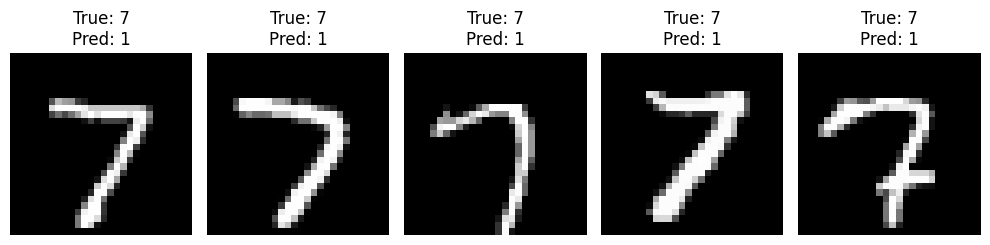

In [ ]:
plt.figure(figsize=(10, 5))
for i in range(5):
    idx = seven_indices[i]
    if predictions[i] == 1:
        plt.subplot(1, 5, i+1)
        plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
        plt.title(f"True: 7\nPred: {predictions[i]}")
        plt.axis('off')
plt.tight_layout()
plt.show()